### Loading the Dataset

In this step, we import the required library (Pandas) and load the dataset 
to begin exploring its structure and content.

The dataset used in this project is the Indian Liver Patient Records dataset.

### Initial Data Preview

We display the first few rows of the dataset to understand 
the structure, feature names, and example values.

This helps verify that the dataset has been loaded correctly.

In [1]:
import pandas as pd

df = pd.read_csv("indian_liver_patient.csv")

df.head()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Dataset
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


### Dataset Structure and Data Types

In this step, we inspect the dataset structure using df.info() 
to identify:

- Number of records
- Number of features
- Data types of each column
- Presence of missing values

Understanding data types is important before performing preprocessing.

In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Dataset                     583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


Observation:

The dataset contains 583 records and 11 features.

Most of the variables are numerical (int64 and float64), 
while the "Gender" column is categorical (object type).

There appear to be minimal missing values in the dataset.

### Class Distribution Analysis

In this step, we visualize the distribution of the target variable (Dataset) 
to understand the balance between the two classes:

1 → Patients with Liver Disease  
2 → Patients without Liver Disease  

This helps determine whether the dataset is balanced or imbalanced, 
which is important for future modeling steps.

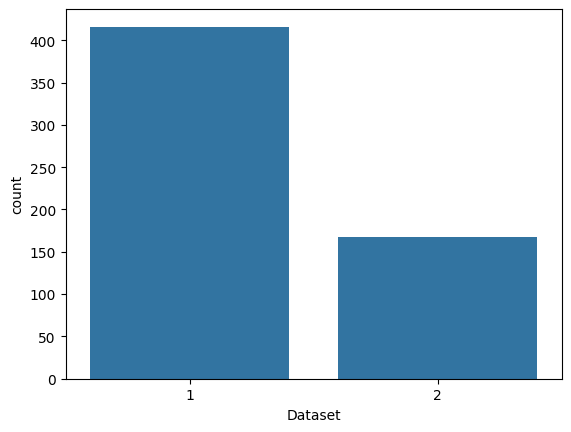

In [3]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x='Dataset',data=df)
plt.show()

Observation:

The majority of the records belong to class 1 (Liver Disease), 
while class 2 (No Liver Disease) contains fewer samples.

This indicates that the dataset is slightly imbalanced, 
which may affect model performance in later phases.

### Correlation Analysis

In this step, we analyze the relationships between numerical features 
using a correlation heatmap.

The correlation matrix helps identify:
- Strong positive relationships
- Strong negative relationships
- Potential redundant features
- Relationships between features and the target variable

Only numerical features are included in this analysis.

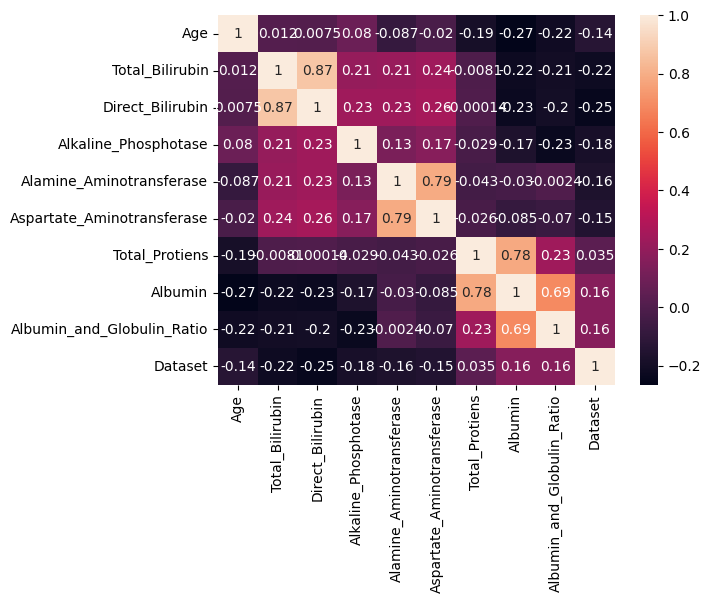

In [6]:
corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True)
plt.show()

Observation:

The heatmap shows moderate correlations between some liver enzyme indicators 
such as Total_Bilirubin and Direct_Bilirubin.

Some features appear strongly related, which may indicate 
that they capture similar medical information.

The target variable (Dataset) shows weak to moderate correlations 
with certain features, suggesting that multiple attributes 
contribute to liver disease detection.

### Feature Distribution Analysis

In this step, we visualize the distribution of all numerical features 
using histograms.

This helps us understand:

- The range of values
- Skewness of the data
- Presence of outliers
- Whether features follow normal distribution

Understanding feature distributions is important before applying 
any preprocessing or modeling techniques.

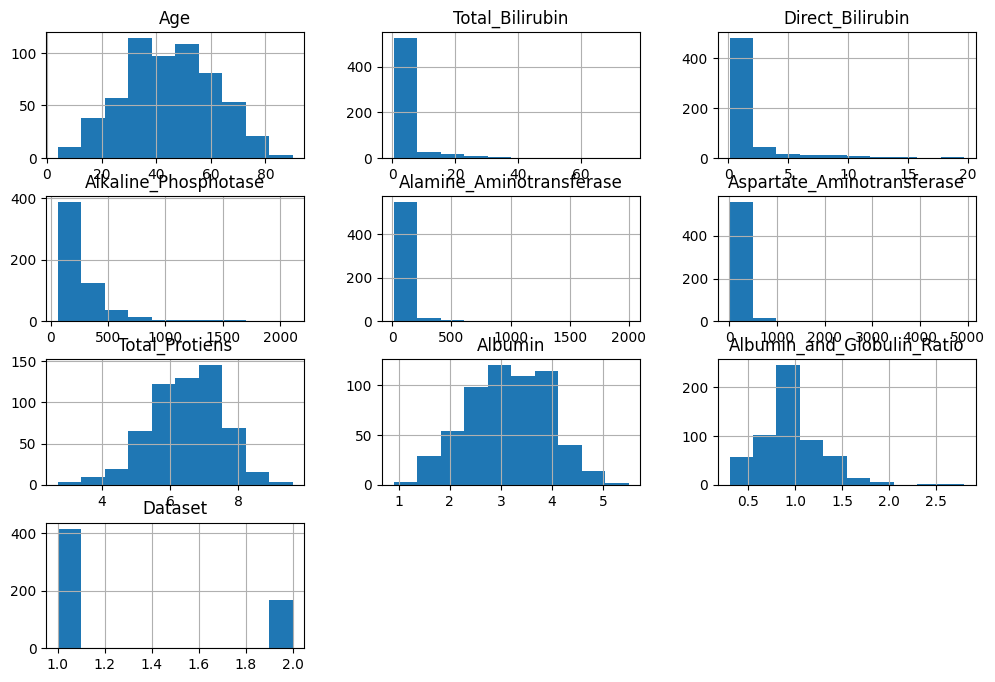

In [7]:
df.select_dtypes(include="number").hist(figsize=(12,8))
plt.show()

Observation:

Several features such as Total_Bilirubin, Direct_Bilirubin, 
and liver enzyme indicators show right-skewed distributions, 
indicating the presence of extreme values.

Some features such as Age and Total_Proteins appear more normally distributed.

These observations suggest that scaling or transformation 
may be required in later modeling phases.

Note:
Only numerical features were included in this visualization.
Categorical variables such as Gender were excluded.

### Missing Values Analysis

In this step, we check for missing values in each feature 
using df.isnull().sum().

Identifying missing values is essential before preprocessing, 
as incomplete data may negatively affect model performance.

In [9]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Dataset                       0
dtype: int64

Observation:

Most features contain no missing values.

However, the feature "Albumin_and_Globulin_Ratio" 
contains a small number of missing values.

Since this feature is numerical, an appropriate imputation strategy 
is required to handle the missing entries.

### Handling Missing Values

To handle missing values in the "Albumin_and_Globulin_Ratio" feature, 
we use median imputation.

The median is chosen instead of the mean because 
the distribution of this feature is slightly skewed, 
and the median is more robust to outliers.

In [11]:
df["Albumin_and_Globulin_Ratio"] = df["Albumin_and_Globulin_Ratio"].fillna(
    df["Albumin_and_Globulin_Ratio"].median()
)

In [12]:
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Dataset                       0
dtype: int64

Observation:

After applying median imputation, 
there are no remaining missing values in the dataset.

The dataset is now complete and ready for further preprocessing steps.

### Encoding Categorical Variables

Machine learning models require numerical input.
Therefore, we convert the categorical variable "Gender" 
into numerical format.

Mapping strategy:
Male → 1  
Female → 0

This transformation allows the feature to be used in 
correlation analysis and future modeling steps.

In [13]:
df["Gender"] = df["Gender"].map({"Male": 1, "Female": 0})

In [14]:
df["Gender"].value_counts()

Gender
1    441
0    142
Name: count, dtype: int64

Observation:

After encoding, the Gender feature is now represented numerically.

The distribution shows that the majority of patients are male, 
which may influence the dataset characteristics.

### Duplicate Records Check

In this step, we check for duplicate records 
to ensure data quality.

Duplicate entries may bias model training 
and lead to inaccurate results.

In [15]:
df.duplicated().sum()

13

Observation:

The dataset contains 13 duplicate records.

These duplicates must be removed 
to maintain data integrity.

### Removing Duplicate Records

We remove duplicate rows from the dataset 
to ensure each record represents a unique patient.

In [16]:
df.drop_duplicates(inplace=True)

In [17]:
df.duplicated().sum()

0

Observation:

After removing duplicates, no duplicate records remain.

The dataset is now clean and ready for modeling.

In [18]:
df.to_csv("preprocessed_data.csv", index=False)
print("Saved successfully")

Saved successfully


### Preprocessed Dataset Ready for Modeling

After completing data cleaning and preprocessing steps, the dataset is now prepared for machine learning modeling.

The following preprocessing steps were applied:

- Handled missing values by replacing them with the median.
- Converted categorical variable (Gender) into numerical format.
- Removed duplicate records to ensure data integrity.
- Verified data types and structure consistency.

The dataset is now clean, structured, and suitable for training classification models.